From the Week 5 toolbox, this implements the second dotpoint:

"sort the communities after their size and show the number of communities and their size distribution"
Four functions are implemented: Sort_Communities_by_Size, Number_of_Communities, Size_Distribution_of_Communities, and Histogram_of_Community_Size.

Implemented by Aaron Carey

Set-up

In [16]:
# Boiler plate set-up copied from Week 1/2 notebooks.
import networkx as nx

import numpy as np
import scipy as sp
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline 
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 16}

plt.rc('font', **font)

In [2]:
from io import StringIO
with open("4932.protein.links.v12.0.txt") as f:
    # Converts the contents of the text file into a string with the 4932. prefix removed
    data = f.read().replace("4932.", "")
G0 = nx.read_weighted_edgelist(
    StringIO(data), # converts the string back into a .txt file, so that it can be input into the function.
    comments="#",
    nodetype=str
)

Separating into communities

In [3]:
# Obtains the communities list from the louvain algorithm.
communities_list = nx.algorithms.community.louvain_communities(G0)


Sorting

In [5]:
def Sort_Communities_by_Size(Communities_list, reverse=True):
    # This function does not modify the input list. Normally, .sort() returns none and directly modifies a list, hence why we copy before sorting it.
    # key=len sorts the communites by the size of the set, i.e., how many nodes there are.
    # reverse=True (default) sorts from biggest to smallest. To do ascending order, set reverse=False.
    copy = Communities_list.copy()
    copy.sort(reverse=reverse, key=len)
    return copy

### The following shows that the function sorts the list correctly without modifying the original list. The first line merely reverse orders the communities list.
# communities_list.sort(reverse=False, key=len)
# for C in communities_list:
#     print(len(C))
# print()
# sorted = Sort_Communities_by_Size(communities_list)
# print((sorted))
# for C in sorted:
#     print(len(C))
# print()
# for C in communities_list:
#     print(len(C))


Getting the Number and size of communities

In [ ]:
def Number_of_Communities(Communities_list):
    return len(Communities_list)

def Size_Distribution_of_Communities(Communities_list):
    return [len(c) for c in Communities_list] # gets size of community for each community in the list

We can generate a different list to see the variance in community making.

In [21]:
# Playing with the variation in community making.
communities_list_2 = nx.algorithms.community.louvain_communities(G0)


In [24]:
print(Number_of_Communities(communities_list))
print(Size_Distribution_of_Communities(Sort_Communities_by_Size(communities_list)))
print()
print(Number_of_Communities(communities_list_2))
print(Size_Distribution_of_Communities(Sort_Communities_by_Size(communities_list_2)))

6
[1933, 1740, 1055, 973, 764, 73]

7
[1970, 1774, 1057, 759, 725, 193, 60]


We can also try the algorithm while trying to make smaller communities.

In [ ]:
# Trying with a higher resolution to make smaller communities
communities_list_3 = nx.algorithms.community.louvain_communities(G0, resolution=2)


In [ ]:
print(Number_of_Communities(communities_list_3))
Size_Distribution_of_Communities(Sort_Communities_by_Size(communities_list_3))
# Creates smaller communites, as expected.

21
737
663
551
545
491
420
371
370
358
335
313
305
249
231
169
142
87
78
71
42
10


Also, may want to show the size distribution as a histogram.


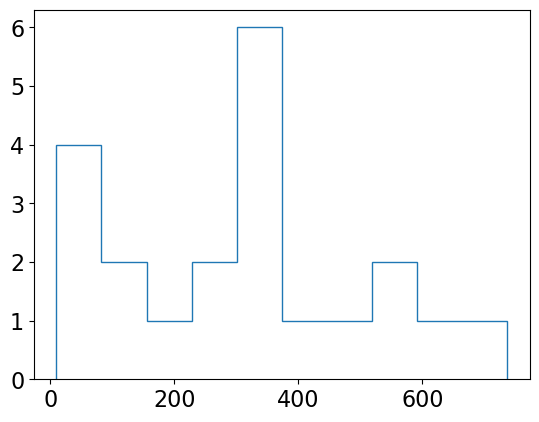

In [ ]:
def Histogram_of_Community_Size(Communities_list):
    Size_list = Size_Distribution_of_Communities(Communities_list)
    # plots Histogram
    counts, bins = np.histogram(Size_list)
    plt.stairs(counts, bins)
    plt.plot()
    return None

Histogram_of_Community_Size(communities_list_3)